In [3]:
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.base import BaseEstimator
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler

from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.model_selection import (
    BaseCrossValidator,
    GridSearchCV
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from xgboost import XGBRegressor, XGBClassifier
from statsmodels.tsa.statespace.sarimax import SARIMAX
import tensorflow as tf

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Libraries loaded.")

Libraries loaded.


In [4]:
# Load your dataset
df = pd.read_csv("financial_regression.csv")

# Convert date
df["date"] = pd.to_datetime(df["date"])

# Sort chronologically
df = df.sort_values("date").reset_index(drop=True)

# Remove days where gold was not traded
df = df.dropna(subset=["gold close"]).reset_index(drop=True)

print("Dataset shape:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())

Dataset shape: (3719, 47)
Date range: 2010-01-14 00:00:00 to 2024-10-23 00:00:00


In [5]:
# ---------------------------------------------------------
# Basic lagged features
# ---------------------------------------------------------

df["Close_Lag1"] = df["gold close"].shift(1)
df["Open_Lag1"] = df["gold open"].shift(1)

# Today's open-to-close return
df["Daily_Return"] = (
    (df["gold close"] - df["gold open"])
    / df["gold open"]
)

# ---------------------------------------------------------
# Calendar features
# ---------------------------------------------------------

df["DayOfWeek"] = df["date"].dt.dayofweek
df["Month"] = df["date"].dt.month
df["Quarter"] = df["date"].dt.quarter
df["DayOfYear"] = df["date"].dt.dayofyear
df["IsMonthEnd"] = df["date"].dt.is_month_end.astype(int)

print("Basic features created.")

Basic features created.


In [6]:
# Tomorrow's gold closing price
df["Target_Next_Close"] = df["gold close"].shift(-1)

In [7]:
# =========================================================
# ADVANCED LOG-RETURN FEATURES
# =========================================================

target_assets = [
    "gold close",
    "silver close",
    "oil close",
    "sp500 close",
    "nasdaq close"
]

lags = [1, 2, 5, 10]

# ---------------------------------------------------------
# Multi-day log returns
# ---------------------------------------------------------

for asset in target_assets:

    col_name = asset.replace(" ", "_")

    for lag in lags:

        df[f"{col_name}_log_ret_{lag}d"] = np.log(
            df[asset] / df[asset].shift(lag)
        )


# ---------------------------------------------------------
# Gold volatility
# ---------------------------------------------------------

gold_ret = df["gold_close_log_ret_1d"]

df["gold_volatility_5d"] = (
    gold_ret.rolling(window=5).std()
)

df["gold_volatility_20d"] = (
    gold_ret.rolling(window=20).std()
)


# ---------------------------------------------------------
# Gold distance from 20-day moving average
# ---------------------------------------------------------

gold_sma20 = (
    df["gold close"]
    .rolling(window=20)
    .mean()
)

df["gold_sma20_dist"] = np.log(
    df["gold close"] / gold_sma20
)


# ---------------------------------------------------------
# Gold/Silver ratio
# ---------------------------------------------------------

df["gold_silver_ratio"] = (
    df["gold close"] / df["silver close"]
)

df["gold_silver_ratio_chg"] = np.log(
    df["gold_silver_ratio"]
    / df["gold_silver_ratio"].shift(1)
)


# ---------------------------------------------------------
# Gold/Oil ratio
# ---------------------------------------------------------

df["gold_oil_ratio"] = (
    df["gold close"] / df["oil close"]
)

df["gold_oil_ratio_chg"] = np.log(
    df["gold_oil_ratio"]
    / df["gold_oil_ratio"].shift(1)
)


# ---------------------------------------------------------
# Gold volume change
# ---------------------------------------------------------

df["gold_volume_change"] = np.log(
    (df["gold volume"] + 1)
    / (df["gold volume"].shift(1) + 1)
)

In [8]:
# ---------------------------------------------------------
# Calendar / cyclical features
# ---------------------------------------------------------

df["Month_sin"] = np.sin(
    2 * np.pi * df["Month"] / 12
)

df["Month_cos"] = np.cos(
    2 * np.pi * df["Month"] / 12
)

df["DayOfYear_sin"] = np.sin(
    2 * np.pi * df["DayOfYear"] / 365.25
)

df["DayOfYear_cos"] = np.cos(
    2 * np.pi * df["DayOfYear"] / 365.25
)

In [9]:
# =========================================================
# NEXT-DAY LOG RETURN TARGET
# =========================================================

df["Target_Log_Return"] = np.log(
    df["gold close"].shift(-1)
    / df["gold close"]
)

In [10]:
# =========================================================
# DIRECTIONAL TARGET
# =========================================================

df["Target_Direction"] = (
    df["Target_Log_Return"] > 0
).astype(int)

print(
    df["Target_Direction"]
    .value_counts(normalize=True)
)

#1 = tomorrow's return is positive
#0 = tomorrow's return is zero or negative

Target_Direction
1    0.522452
0    0.477548
Name: proportion, dtype: float64


In [11]:
df = df.dropna(
    subset=[
        "Target_Next_Close",
        "Target_Log_Return"
    ]
).reset_index(drop=True)

print("Final dataset shape:", df.shape)

Final dataset shape: (3718, 90)


In [12]:
raw_numeric_features = [
    "sp500 open",
    "sp500 high",
    "sp500 low",
    "sp500 close",

    "nasdaq open",
    "nasdaq high",
    "nasdaq low",
    "nasdaq close",

    "silver close",
    "oil close",
    "platinum close",
    "palladium close",

    "gold open",
    "gold high",
    "gold low",
    "gold close",
    "gold volume",

    "Close_Lag1",
    "Open_Lag1",
    "Daily_Return"
]

raw_categorical_features = [
    "DayOfWeek",
    "Month",
    "Quarter",
    "DayOfYear",
    "IsMonthEnd"
]

raw_features = (
    raw_numeric_features
    + raw_categorical_features
)

raw_target = "Target_Next_Close"

In [13]:
log_numeric_features = [
    "Daily_Return",

    # 1-day returns
    "gold_close_log_ret_1d",
    "silver_close_log_ret_1d",
    "oil_close_log_ret_1d",
    "sp500_close_log_ret_1d",
    "nasdaq_close_log_ret_1d",

    # 2-day returns
    "gold_close_log_ret_2d",
    "silver_close_log_ret_2d",
    "oil_close_log_ret_2d",
    "sp500_close_log_ret_2d",
    "nasdaq_close_log_ret_2d",

    # 5-day returns
    "gold_close_log_ret_5d",
    "silver_close_log_ret_5d",
    "oil_close_log_ret_5d",
    "sp500_close_log_ret_5d",
    "nasdaq_close_log_ret_5d",

    # 10-day returns
    "gold_close_log_ret_10d",
    "silver_close_log_ret_10d",
    "oil_close_log_ret_10d",
    "sp500_close_log_ret_10d",
    "nasdaq_close_log_ret_10d",

    # Volatility
    "gold_volatility_5d",
    "gold_volatility_20d",

    # Trend
    "gold_sma20_dist",

    # Cross-market
    "gold_silver_ratio_chg",
    "gold_oil_ratio_chg",

    # Volume
    "gold_volume_change",

    # Cyclical time
    "Month_sin",
    "Month_cos",
    "DayOfYear_sin",
    "DayOfYear_cos"
]

log_categorical_features = [
    "DayOfWeek",
    "IsMonthEnd"
]

log_features = (
    log_numeric_features
    + log_categorical_features
)

log_target = "Target_Log_Return"
classification_target = "Target_Direction"

In [14]:
class PurgedTimeSeriesCV(BaseCrossValidator):
    """
    Expanding-window time-series CV with a purge/embargo gap.

    Training observations always occur before validation observations.

    Parameters
    ----------
    n_splits : int
        Number of validation folds.

    test_size : int
        Number of observations in each validation fold.

    purge_size : int
        Number of observations removed immediately before
        the validation set.

    embargo_size : int
        Additional gap between training and validation.
        For a strictly chronological walk-forward split,
        this acts as an additional gap before validation.
    """

    def __init__(
        self,
        n_splits=3,
        test_size=200,
        purge_size=1,
        embargo_size=1
    ):
        self.n_splits = n_splits
        self.test_size = test_size
        self.purge_size = purge_size
        self.embargo_size = embargo_size

    def split(self, X, y=None, groups=None):

        n_samples = len(X)

        # Total gap between train and validation
        gap = (
            self.purge_size
            + self.embargo_size
        )

        # Last possible validation fold
        first_test_start = (
            n_samples
            - self.n_splits * self.test_size
        )

        if first_test_start <= gap:
            raise ValueError(
                "Not enough observations for the "
                "requested number of splits."
            )

        for i in range(self.n_splits):

            test_start = (
                first_test_start
                + i * self.test_size
            )

            test_end = (
                test_start
                + self.test_size
            )

            train_end = test_start - gap

            train_indices = np.arange(
                0,
                train_end
            )

            test_indices = np.arange(
                test_start,
                min(test_end, n_samples)
            )

            yield train_indices, test_indices

    def get_n_splits(
        self,
        X=None,
        y=None,
        groups=None
    ):
        return self.n_splits

In [23]:
outer_windows = generate_purged_walk_forward_windows(
    df,
    train_years=4,
    test_start_year=2014,
    test_end_year=2024,
    purge_size=1,
    embargo_size=1
)

print(
    f"Generated {len(outer_windows)} "
    "purged walk-forward windows."
)

for w in outer_windows:

    train = df.iloc[w["train_indices"]]
    test = df.iloc[w["test_indices"]]

    print(
        f"Train: {train['date'].min().date()} "
        f"to {train['date'].max().date()} | "
        f"Test: {test['date'].min().date()} "
        f"to {test['date'].max().date()} | "
        f"Train n={len(train)}, "
        f"Test n={len(test)}"
    )

Generated 11 purged walk-forward windows.
Train: 2010-01-14 to 2013-12-27 | Test: 2014-01-02 to 2014-12-31 | Train n=996, Test n=252
Train: 2011-01-03 to 2014-12-29 | Test: 2015-01-02 to 2015-12-31 | Train n=1004, Test n=252
Train: 2012-01-03 to 2015-12-29 | Test: 2016-01-04 to 2016-12-30 | Train n=1004, Test n=252
Train: 2013-01-02 to 2016-12-28 | Test: 2017-01-03 to 2017-12-29 | Train n=1006, Test n=251
Train: 2014-01-02 to 2017-12-27 | Test: 2018-01-02 to 2018-12-31 | Train n=1005, Test n=251
Train: 2015-01-02 to 2018-12-27 | Test: 2019-01-02 to 2019-12-31 | Train n=1004, Test n=252
Train: 2016-01-04 to 2019-12-27 | Test: 2020-01-02 to 2020-12-31 | Train n=1004, Test n=253
Train: 2017-01-03 to 2020-12-29 | Test: 2021-01-04 to 2021-12-31 | Train n=1005, Test n=252
Train: 2018-01-02 to 2021-12-29 | Test: 2022-01-03 to 2022-12-30 | Train n=1006, Test n=251
Train: 2019-01-02 to 2022-12-28 | Test: 2023-01-03 to 2023-12-29 | Train n=1006, Test n=250
Train: 2020-01-02 to 2023-12-27 | Test:

In [24]:
def generate_purged_walk_forward_windows(
    df,
    train_years=4,
    test_start_year=2014,
    test_end_year=2024,
    purge_size=1,
    embargo_size=1
):
    """
    Generate chronological walk-forward windows.

    Each fold uses:
        4 years training
        purge + embargo gap
        1 calendar year testing

    The final test year (2024) may be a partial year
    because the dataset ends on 2024-10-23.
    """

    windows = []

    for test_year in range(
        test_start_year,
        test_end_year + 1
    ):

        train_start = test_year - train_years
        train_end = test_year - 1

        train_start_date = pd.Timestamp(
            f"{train_start}-01-01"
        )

        train_end_date = pd.Timestamp(
            f"{train_end}-12-31"
        )

        test_start_date = pd.Timestamp(
            f"{test_year}-01-01"
        )

        test_end_date = pd.Timestamp(
            f"{test_year}-12-31"
        )

        train_mask = (
            (df["date"] >= train_start_date)
            &
            (df["date"] <= train_end_date)
        )

        test_mask = (
            (df["date"] >= test_start_date)
            &
            (df["date"] <= test_end_date)
        )

        train_indices = np.where(train_mask)[0]
        test_indices = np.where(test_mask)[0]

        if len(train_indices) == 0 or len(test_indices) == 0:
            continue

        # Total observations removed between
        # training and testing
        gap = purge_size + embargo_size

        if len(train_indices) <= gap:
            continue

        train_indices = train_indices[:-gap]

        windows.append({
            "train_start": train_start,
            "train_end": train_end,
            "test_year": test_year,
            "train_indices": train_indices,
            "test_indices": test_indices
        })

    return windows

In [25]:
def make_scaled_preprocessor(
    numeric_features,
    categorical_features
):

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(
            strategy="median"
        )),
        ("scaler", RobustScaler())
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(
            strategy="most_frequent"
        )),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ])

    return ColumnTransformer([
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ])

In [26]:
def make_tree_preprocessor(
    numeric_features,
    categorical_features
):

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(
            strategy="median"
        ))
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(
            strategy="most_frequent"
        )),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ])

    return ColumnTransformer([
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ])

In [27]:
def regression_metrics(y_true, y_pred):

    return {
        "MAE": mean_absolute_error(
            y_true,
            y_pred
        ),

        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        ),

        "R²": r2_score(
            y_true,
            y_pred
        )
    }

## Phase 4: Regression Model Comparison

All models below predict `Target_Log_Return` using the same `log_features` and the existing purged walk-forward windows. The 2024 fold is reported separately as the final holdout. SARIMA and SARIMAX use rolling one-step forecasts: each realized test return is incorporated before forecasting the next day, while model parameters remain fixed.

In [28]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R²": r2_score(y_true, y_pred)
    }


def predict_linear_log(train, test):
    pipeline = Pipeline([
        ("preprocessor", make_scaled_preprocessor(
            log_numeric_features,
            log_categorical_features
        )),
        ("model", LinearRegression())
    ])

    pipeline.fit(train[log_features], train[log_target])
    return pipeline.predict(test[log_features])


def predict_xgb_log(train, test):
    pipeline = Pipeline([
        ("preprocessor", make_tree_preprocessor(
            log_numeric_features,
            log_categorical_features
        )),
        ("model", XGBRegressor(
            objective="reg:squarederror",
            n_estimators=200,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            random_state=SEED,
            n_jobs=-1
        ))
    ])

    pipeline.fit(train[log_features], train[log_target])
    return pipeline.predict(test[log_features])

In [29]:
# State-space model settings for daily log returns.
# d=0 is used because the target is a return series rather than a price series.
ARIMA_ORDER = (1, 0, 1)
SEASONAL_ORDER = (1, 0, 1, 5)  # weekly pattern across five trading days


def predict_sarima(train, test):
    """SARIMA rolling one-step forecasts with fixed fitted parameters."""
    y_train = pd.Series(
        train[log_target].to_numpy(dtype=float),
        index=pd.RangeIndex(len(train))
    )
    y_test = pd.Series(
        test[log_target].to_numpy(dtype=float),
        index=pd.RangeIndex(len(train), len(train) + len(test))
    )

    fitted = SARIMAX(
        y_train,
        order=ARIMA_ORDER,
        seasonal_order=SEASONAL_ORDER,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False, maxiter=100)

    # Appending observed test returns updates the state for the next forecast;
    # refit=False keeps estimated model parameters fixed.
    extended = fitted.append(y_test, refit=False)
    forecast = extended.get_prediction(
        start=len(y_train),
        end=len(y_train) + len(y_test) - 1
    )
    return np.asarray(forecast.predicted_mean, dtype=float)


def prepare_sarimax_exog(train, test):
    """Fit imputing/scaling on training rows, then transform both periods."""
    preprocessor = make_scaled_preprocessor(
        log_numeric_features,
        log_categorical_features
    )

    X_train = preprocessor.fit_transform(train[log_features])
    X_test = preprocessor.transform(test[log_features])

    if hasattr(X_train, "toarray"):
        X_train = X_train.toarray()
    if hasattr(X_test, "toarray"):
        X_test = X_test.toarray()

    X_train = np.asarray(X_train, dtype=float)
    X_test = np.asarray(X_test, dtype=float)

    train_index = pd.RangeIndex(len(train))
    test_index = pd.RangeIndex(len(train), len(train) + len(test))
    X_train = pd.DataFrame(X_train, index=train_index)
    X_test = pd.DataFrame(X_test, index=test_index)
    return X_train, X_test


def predict_sarimax(train, test):
    """SARIMAX rolling one-step forecasts using the same log features."""
    X_train, X_test = prepare_sarimax_exog(train, test)
    y_train = pd.Series(
        train[log_target].to_numpy(dtype=float),
        index=pd.RangeIndex(len(train))
    )
    y_test = pd.Series(
        test[log_target].to_numpy(dtype=float),
        index=pd.RangeIndex(len(train), len(train) + len(test))
    )

    fitted = SARIMAX(
        y_train,
        exog=X_train,
        order=ARIMA_ORDER,
        seasonal_order=SEASONAL_ORDER,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False, maxiter=100)

    extended = fitted.append(y_test, exog=X_test, refit=False)
    forecast = extended.get_prediction(
        start=len(y_train),
        end=len(y_train) + len(y_test) - 1
    )
    return np.asarray(forecast.predicted_mean, dtype=float)

In [30]:
LOOKBACK = 20
LSTM_EPOCHS = 50
LSTM_BATCH_SIZE = 32


def make_lstm_sequences(X, y, lookback):
    """Each feature window ends on the row whose next-day return is predicted."""
    X_sequences, y_sequences = [], []

    for end in range(lookback - 1, len(X)):
        X_sequences.append(X[end - lookback + 1:end + 1])
        y_sequences.append(y[end])

    return (
        np.asarray(X_sequences, dtype=np.float32),
        np.asarray(y_sequences, dtype=np.float32)
    )


def build_lstm(input_shape):
    model = keras.Sequential([
        keras.Input(shape=input_shape),
        layers.LSTM(64),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dense(1)
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse"
    )
    return model


def predict_lstm_log(train, test, test_indices):
    """Train on the fold and predict each test row with a 20-day feature window."""
    preprocessor = make_scaled_preprocessor(
        log_numeric_features,
        log_categorical_features
    )

    X_train = preprocessor.fit_transform(train[log_features])
    X_test = preprocessor.transform(test[log_features])

    if hasattr(X_train, "toarray"):
        X_train = X_train.toarray()
    if hasattr(X_test, "toarray"):
        X_test = X_test.toarray()

    X_train = np.asarray(X_train, dtype=np.float32)
    X_test = np.asarray(X_test, dtype=np.float32)
    y_train = train[log_target].to_numpy(dtype=np.float32)

    X_train_seq, y_train_seq = make_lstm_sequences(
        X_train,
        y_train,
        LOOKBACK
    )
    if len(X_train_seq) == 0:
        raise ValueError("Training fold is shorter than the LSTM lookback window.")

    # Use the immediately preceding rows as context, including the purge gap,
    # so the first test sequence has contiguous daily feature history.
    first_test_index = int(test_indices[0])
    context_start = first_test_index - (LOOKBACK - 1)
    context = df.iloc[context_start:first_test_index][log_features]
    X_context = preprocessor.transform(context)
    if hasattr(X_context, "toarray"):
        X_context = X_context.toarray()
    X_context = np.asarray(X_context, dtype=np.float32)

    X_test_with_context = np.concatenate([X_context, X_test], axis=0)
    X_test_seq = np.asarray([
        X_test_with_context[i:i + LOOKBACK]
        for i in range(len(X_test))
    ], dtype=np.float32)

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)
    model = build_lstm(
        input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])
    )

    model.fit(
        X_train_seq,
        y_train_seq,
        epochs=LSTM_EPOCHS,
        batch_size=LSTM_BATCH_SIZE,
        validation_split=0.1,
        shuffle=False,
        callbacks=[keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )],
        verbose=0
    )
    return model.predict(X_test_seq, verbose=0).ravel()

In [31]:
# Same-day zero-return benchmark, plus the four fitted model families.
MODEL_NAMES = [
    "Linear Regression",
    "SARIMA",
    "SARIMAX",
    "LSTM",
    "XGBoost",
    "Zero Return Baseline"
]

log_results = []
price_results = []
predictions_store = {}

for w in outer_windows:
    train = df.iloc[w["train_indices"]].copy().reset_index(drop=True)
    test = df.iloc[w["test_indices"]].copy().reset_index(drop=True)
    test_indices = w["test_indices"]

    y_true_return = test[log_target].to_numpy(dtype=float)
    y_true_price = test["Target_Next_Close"].to_numpy(dtype=float)

    model_predictions = {
        "Linear Regression": predict_linear_log(train, test),
        "SARIMA": predict_sarima(train, test),
        "SARIMAX": predict_sarimax(train, test),
        "LSTM": predict_lstm_log(train, test, test_indices),
        "XGBoost": predict_xgb_log(train, test),
        "Zero Return Baseline": np.zeros(len(test))
    }

    for model_name, y_pred_return in model_predictions.items():
        y_pred_return = np.asarray(y_pred_return, dtype=float).reshape(-1)
        if len(y_pred_return) != len(y_true_return):
            raise ValueError(
                f"{model_name} returned {len(y_pred_return)} predictions "
                f"for {len(y_true_return)} test rows."
            )

        return_scores = regression_metrics(y_true_return, y_pred_return)
        y_pred_price = test["gold close"].to_numpy(dtype=float) * np.exp(y_pred_return)
        price_scores = regression_metrics(y_true_price, y_pred_price)

        log_results.append({
            "Test Year": w["test_year"],
            "Model": model_name,
            **return_scores
        })
        price_results.append({
            "Test Year": w["test_year"],
            "Model": model_name,
            **price_scores
        })
        predictions_store[(w["test_year"], model_name)] = {
            "date": test["date"].to_numpy(),
            "actual_return": y_true_return,
            "predicted_return": y_pred_return,
            "actual_price": y_true_price,
            "predicted_price": y_pred_price
        }

    print(
        f"Finished {w['test_year']}: "
        f"train n={len(train)}, test n={len(test)}"
    )

log_results_df = pd.DataFrame(log_results)
price_results_df = pd.DataFrame(price_results)

Finished 2014: train n=996, test n=252
Finished 2015: train n=1004, test n=252
Finished 2016: train n=1004, test n=252
Finished 2017: train n=1006, test n=251
Finished 2018: train n=1005, test n=251
Finished 2019: train n=1004, test n=252
Finished 2020: train n=1004, test n=253
Finished 2021: train n=1005, test n=252
Finished 2022: train n=1006, test n=251
Finished 2023: train n=1006, test n=250
Finished 2024: train n=1004, test n=204


### Results

The first table reports errors in log-return units. The second reports errors after converting each predicted return into a predicted next close, so its MAE and RMSE are in gold-price units. The 2024 tables are the final holdout results.

In [32]:
# Log-return results by test year and mean across all folds.
display(
    log_results_df.pivot(
        index="Test Year",
        columns="Model",
        values="RMSE"
    ).reindex(columns=MODEL_NAMES).round(6)
)

log_summary = (
    log_results_df
    .groupby("Model")[["MAE", "RMSE", "R²"]]
    .mean()
    .reindex(MODEL_NAMES)
)
display(log_summary.round(6))

# Price-unit results by test year and mean across all folds.
display(
    price_results_df.pivot(
        index="Test Year",
        columns="Model",
        values="RMSE"
    ).reindex(columns=MODEL_NAMES).round(3)
)

price_summary = (
    price_results_df
    .groupby("Model")[["MAE", "RMSE", "R²"]]
    .mean()
    .reindex(MODEL_NAMES)
)
display(price_summary.round(3))

# Final holdout tables. Keep 2024 out of model-selection decisions.
holdout_log_results = (
    log_results_df[log_results_df["Test Year"] == 2024]
    .set_index("Model")[["MAE", "RMSE", "R²"]]
    .reindex(MODEL_NAMES)
)
holdout_price_results = (
    price_results_df[price_results_df["Test Year"] == 2024]
    .set_index("Model")[["MAE", "RMSE", "R²"]]
    .reindex(MODEL_NAMES)
)

print("2024 final holdout — log-return metrics")
display(holdout_log_results.round(6))
print("2024 final holdout — gold-price metrics")
display(holdout_price_results.round(3))

Model,Linear Regression,SARIMA,SARIMAX,LSTM,XGBoost,Zero Return Baseline
Test Year,,,,,,
2014,0.009426,0.009348,0.016110,0.009358,0.009664,0.009328
2015,0.009248,0.008934,0.009289,0.009948,0.009532,0.008904
2016,0.010729,0.010131,0.010701,0.010163,0.010707,0.010129
2017,0.006669,0.006264,0.006677,0.006334,0.007388,0.006265
2018,0.006174,0.006052,0.006317,0.006455,0.006514,0.006079
2019,0.007579,0.007358,0.007561,0.007359,0.007763,0.007367
2020,0.013805,0.012388,0.013799,0.086984,0.013562,0.012377
2021,0.008823,0.008656,0.016066,0.008559,0.009022,0.008573
2022,0.009827,0.009588,0.009833,0.009642,0.010190,0.009565


,MAE,RMSE,R²
Model,,,
Linear Regression,0.006822,0.009074,-0.077871
SARIMA,0.006567,0.008763,-0.009764
SARIMAX,0.011011,0.014294,-2.530365
LSTM,0.008111,0.015665,-4.466398
XGBoost,0.006960,0.009268,-0.136300
Zero Return Baseline,0.006540,0.008739,-0.004575


Model,Linear Regression,SARIMA,SARIMAX,LSTM,XGBoost,Zero Return Baseline
Test Year,,,,,,
2014,1.135,1.122,1.942,1.123,1.160,1.120
2015,1.034,1.000,1.039,1.111,1.065,0.996
2016,1.278,1.208,1.275,1.212,1.276,1.207
2017,0.798,0.750,0.799,0.758,0.885,0.751
2018,0.743,0.728,0.760,0.777,0.782,0.731
2019,1.015,0.985,1.013,0.986,1.038,0.986
2020,2.277,2.048,2.276,12.065,2.242,2.047
2021,1.486,1.457,2.706,1.441,1.522,1.443
2022,1.658,1.620,1.659,1.629,1.718,1.614


,MAE,RMSE,R²
Model,,,
Linear Regression,1.019,1.357,0.956
SARIMA,0.985,1.314,0.958
SARIMAX,1.805,2.342,0.852
LSTM,1.199,2.237,0.882
XGBoost,1.038,1.383,0.953
Zero Return Baseline,0.980,1.310,0.959


2024 final holdout — log-return metrics


,MAE,RMSE,R²
Model,,,
Linear Regression,0.007083,0.009040,0.000214
SARIMA,0.007126,0.009165,-0.027507
SARIMAX,0.028166,0.035302,-14.245553
LSTM,0.007006,0.009089,-0.010517
XGBoost,0.007064,0.009135,-0.020799
Zero Return Baseline,0.007085,0.009141,-0.022090


2024 final holdout — gold-price metrics


,MAE,RMSE,R²
Model,,,
Linear Regression,1.537,1.975,0.988
SARIMA,1.547,2.001,0.988
SARIMAX,6.086,7.680,0.825
LSTM,1.520,1.981,0.988
XGBoost,1.532,1.993,0.988
Zero Return Baseline,1.538,1.996,0.988


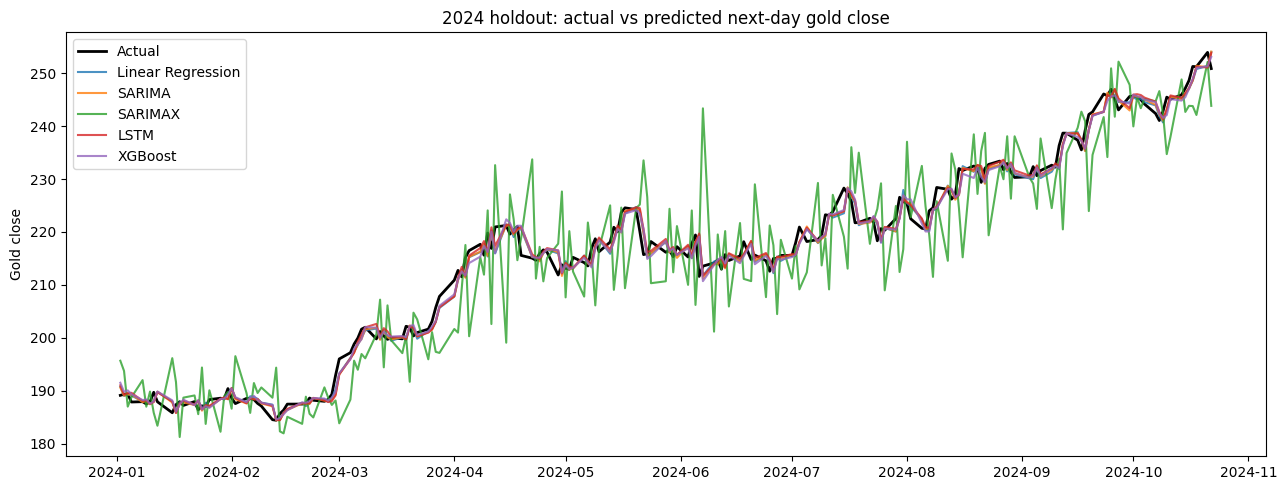

In [33]:
# Actual versus predicted next-day gold close for the 2024 final holdout.
HOLDOUT_YEAR = 2024
holdout = predictions_store[(HOLDOUT_YEAR, "Linear Regression")]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(holdout["date"], holdout["actual_price"], label="Actual", color="black", lw=2)

for model_name in MODEL_NAMES:
    if model_name == "Zero Return Baseline":
        continue
    result = predictions_store[(HOLDOUT_YEAR, model_name)]
    ax.plot(
        result["date"],
        result["predicted_price"],
        label=model_name,
        alpha=0.8
    )

ax.set_title("2024 holdout: actual vs predicted next-day gold close")
ax.set_ylabel("Gold close")
ax.legend()
plt.tight_layout()
plt.show()